<a href="https://colab.research.google.com/github/hyunbin1024/GEOG761/blob/lab2/GEO761_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
The primary objective of this lab is to familiarise you with the basic mechanics that allow you to get hold of satellite data for the purposes of carrying out machine learning. The second objective is for you to put into practice some of the theory that we covered in lectures 1 and 2, in order that you can start to understand some of the specific quirks and potentially powerful attributes of satellite data when it comes to applying machine learning techniques.

This lab has drawn upon the following sources, tutorials and repos:


*   https://geemap.org/
*   https://developers.google.com/earth-engine

Whenever you see a numbered question, e.g. '(1)', make sure that you answer it in the answer proforma and submit the resulting document on Canvas. Only submit in .docx or .pdf formats (we cannot open 'pages' etc docs on Canvas).

If you want to submit code as your 'working' OR we ask you to give your code as part of the answer, give a link in your proforma document to a Colab notebook that is stored in a place we can access (your own GitHub account for example!).

Some of the questions will be relatively simple and are designed to get you thinking about the nature of the code and what it is doing, whilst also requiring you to pull in theoretical knowledge from the lectures. Other questions are exercises that ask you to both apply this knowledege to a new challenge and/or require you to independently go and seek answers.

In all cases I encourage you to give it a go, even if you do not have the full answer. Particularly for the larger challenges ('Exercises'), marks are awarded for workings and I want to see your thought process in action via the code you write.

Use text comments as demonstrated in these lab instructions to explain your thinking and communicate with the person marking your work.

I use both comments above chunks of code to tell you the overall objectives of that code, and inline comments to highlight specific features and elements to be aware of (formatted like this to draw your attention '#<-').

You are expected to present outputs to a professional standard. This means maps must have scales, north arrows and legends that are readable. For a good guide to all matters professional figure drawing, see this Nature guide:
*    https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/.

A portion of the marks are for presentation and communication.

# Set up

In [1]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='basic-thinker-504003-q7')

In [2]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
!pip install geemap

In [3]:
import geemap

# Loading a map and displaying satellite data

In [4]:
# Use the built in functions to load an ipyleaflet basemap (this is a UI to explore and see what we are doing)
# Note that I used to show you Open Street Map here, but there is currently a tile/scraper battle going on, and notebooks have been caught in the cross-fire.
Map = geemap.Map(center=(-41, 172), zoom=4, basemap="HYBRID")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [5]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-41, 172), zoom=4) #<- note the lat-lon coordinate pair here
Map.add_basemap("USGS.USImageryTopo")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [6]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
Map = geemap.Map(center=(-36.8485, 174.7633), zoom=8, basemap="OpenTopoMap") # Auckland City -36.8485° S, 174.7633° E
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [7]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [8]:
# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5) #<- note vis params called from the dictionary we set up before
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map.addLayer(states, {}, "US States")

In [9]:
# Dump all of this into the map view and take a look...
# Scroll around (look at both NZ and USA), check and uncheck the layers in the layer menu on the top-right.
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

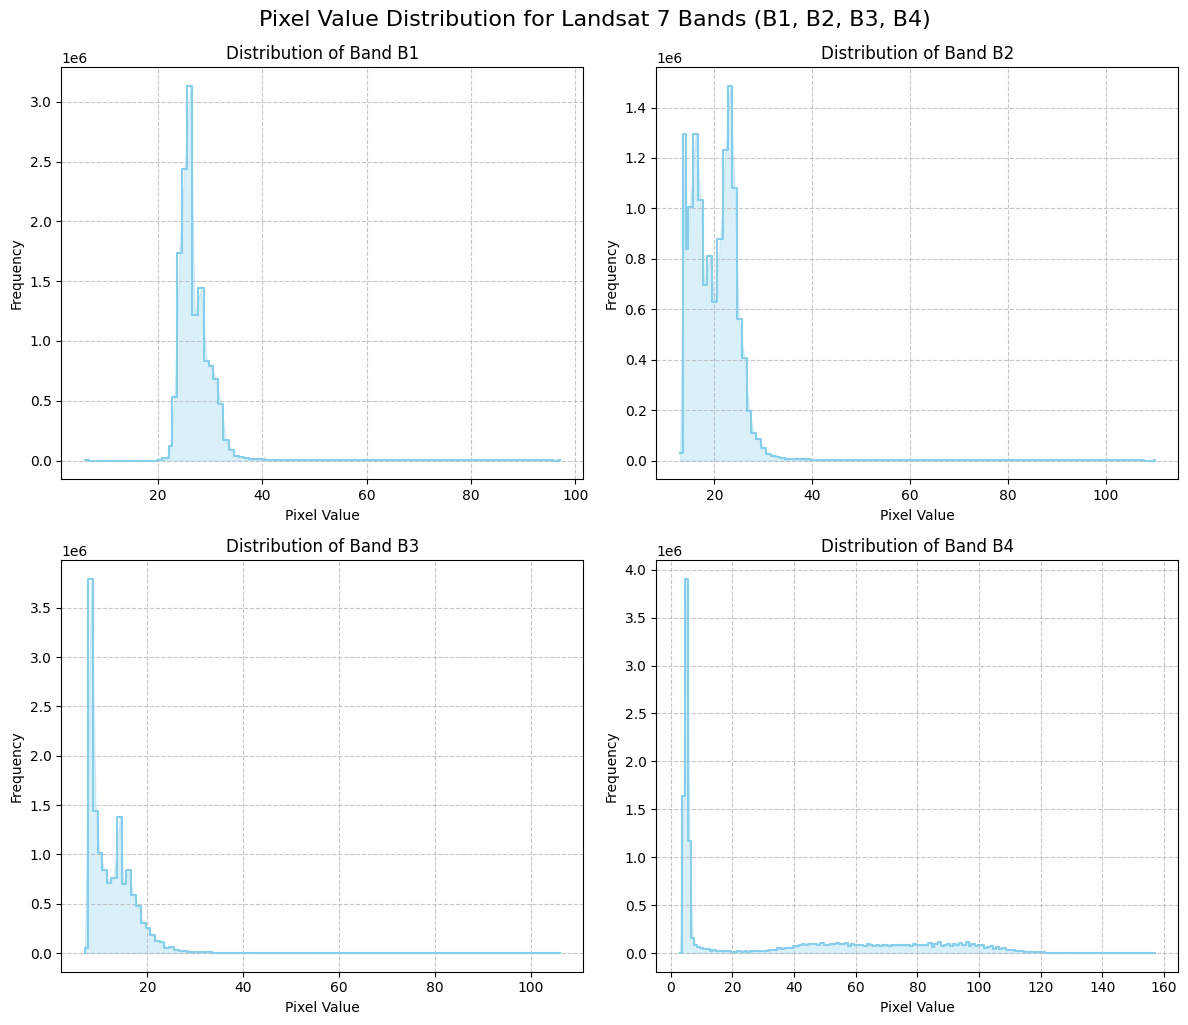

In [10]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

# Define the specific bands to plot for Landsat 7 as requested
landsat7_bands_selected = ['B1', 'B2', 'B3', 'B4']

# Define the region of interest for histogram calculation.
# Reusing the buffer around Auckland as a representative area.
region_for_hist = ee.Geometry.Point([174.7633, -36.8485]).buffer(50000).bounds() # 50km buffer around Auckland

plt.figure(figsize=(12, 10)) # Adjusted figure size for 2x2 layout

for i, band in enumerate(landsat7_bands_selected):
    # Calculate histogram for each selected band
    histogram = landsat7.select(band).reduceRegion(
        reducer=ee.Reducer.histogram(),
        geometry=region_for_hist,
        scale=30, # Landsat resolution
        maxPixels=1e9
    )

    # Get the histogram data. ee.Reducer.histogram returns a dictionary.
    hist_data = histogram.get(band).getInfo()

    if hist_data and 'bucketMeans' in hist_data and 'histogram' in hist_data:
        x_values = hist_data['bucketMeans']
        y_counts = hist_data['histogram']

        plt.subplot(2, 2, i + 1) # Create 2x2 subplots for 4 bands
        plt.plot(x_values, y_counts, drawstyle='steps-mid', color='skyblue')
        plt.fill_between(x_values, y_counts, color='skyblue', alpha=0.3)

        plt.title(f'Distribution of Band {band}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        print(f"No valid histogram data found for Band {band}.")

plt.tight_layout()
plt.suptitle('Pixel Value Distribution for Landsat 7 Bands (B1, B2, B3, B4)', y=1.02, fontsize=16)
plt.show()

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://weather.ndc.nasa.gov/sport/training/quickGuides/rgb/QuickGuide_TrueColorRGB_NASA_SPoRT.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [11]:
Map = geemap.Map(center=(-40.9006, 174.8860), zoom=5, basemap="OpenTopoMap") # New Zealand -40.9006° S, 174.8860° E

Map.addLayer(
    landsat7, {"bands": ["B3", "B2", "B1"], "min": 0, "max": 50, "gamma":1.4}, "Landsat 7 Fixed" #<- note vis params in a dictionary here inside the add layer call
)

Map

Map(center=[-40.9006, 174.886], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topr…

# Spectral reflectance curves
Next we we will generate a spectral reflectance curve for a given area.
This is a useful tool when you are considering if a given target has spectral characteristics for identification in ML. If everything has the same spectral signature, then you need to take a different approach to a simple spectral classification, as might have been the first instinct of a classical remote sensing scientist before the advent of machine learning.

In [12]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

In [13]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

In [14]:
# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

In [15]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

**Important sidenote**

The 'reduce' operation is a key concept in the backend of how Google is storing and serving us large quanities of satellite data. GEE uses 'reducers' in multiple ways, many of which are not always immediately intuitive. Check out the docs for more information:

*   https://developers.google.com/earth-engine/guides/reducers_intro

Here we are using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region:

In [16]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

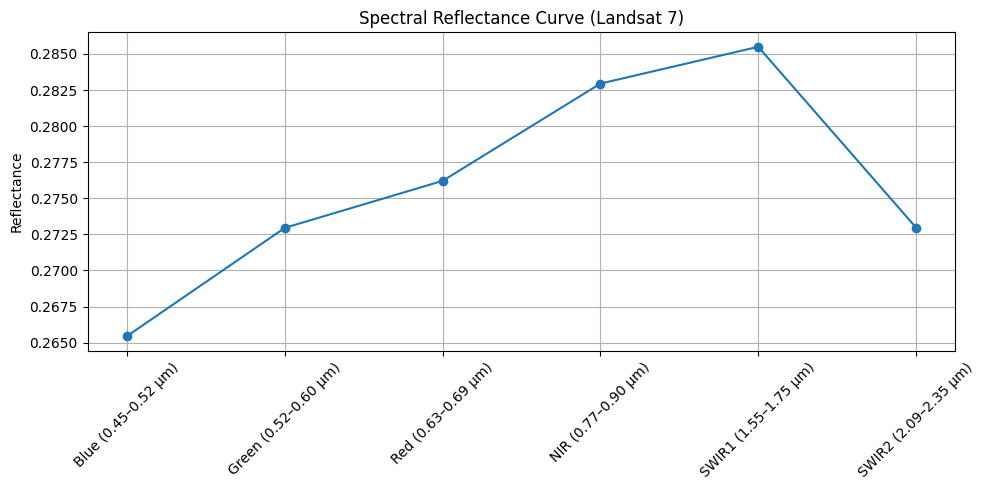

In [17]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

In [18]:
# Define small region around Auckland, NZ
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(500).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first() #<- note the filtering step that is being applied here! We are taking the first image in a sorted by cloud cover response.

# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

Image ID: LE07_L2SP_073086_20020827_20200916_02_T1
Cloud Cover (whole scene): 1


In [19]:
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

**Important side note**

In the function above we are using a bitwise operation in order to search through the quality assurance (QA) band of the image. Different satellites have different bit-masks. Read more about bitmasks and how they are used here:
*   https://spatialthoughts.com/2021/08/19/qa-bands-bitmasks-gee/



**Another important side note**

You will have noticed that we are frequently running code and not seeing anything happen in terms of output in the cell or changes in the RAM/Disk of the Colab instance (check the small graphs top right). This is deliberate! Satellite data is large and hard to wrangle. GEE does a lot of the work for us, hence we can explore and get into it so quickly. Part of how it does this is by not executing any of your API calls until you specifically ask for an output to be sent back to you. Prior to calling an output (usually through a 'AddLayer' or similar call), when using the GEE/EE API you are essentially chaining together a lot of dot-operators (e.g. '.sort \ .reduce') into a series of instructions that are verified, but only then acted on when required.

This is the result of a 'client vs. server' approach. For more detail, that will help you understand why you can and cannot do certain things, see:
*   https://developers.google.com/earth-engine/guides/client_server



In [20]:
# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Total Pixels: 1394
Valid (non-cloud) Pixels: 1050
Estimated Cloud Coverage in ROI: 24.68%


In [21]:
# Visualize the before and after
Map = geemap.Map(center=[-36.8485, 174.7633], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}

Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [22]:
# Define small region around Auckland, NZ
import pandas as pd

# List to store average cloud coverage for each year
annual_cloud_coverage_data = []

for year in [2005, 2010, 2015]:
    images = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
        .filterBounds(region) \
        .filterDate(f"{year}-01-01", f"{year+1}-01-01")

    # Get number of images in the collection
    print(f"Number of images in {year}: {images.size().getInfo()}")

    masked_images = images.map(mask_clouds)

    # Convert client-side total_pixels to an ee.Number for server-side computation
    ee_total_pixels_constant = ee.Number(total_pixels)

    def calculate_cloud_coverage(image):
        # Count valid pixels in the masked image (server-side operation)
        valid_pixels_count = image.select('SR_B3').reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=region,
            scale=30,
            maxPixels=1e9
        ).get('SR_B3')

        # Calculate cloud coverage as an ee.Number (server-side operation)
        cloud_coverage_pct = ee.Number(100).multiply(
            ee.Number(1).subtract(ee.Number(valid_pixels_count).divide(ee_total_pixels_constant))
        )

        # Return an ee.Feature with the image ID and calculated cloud coverage
        return ee.Feature(None, {
            'ImageID': image.get('LANDSAT_PRODUCT_ID'),
            'CloudCoverage': cloud_coverage_pct
        })

    # Apply the server-side function to the image collection
    cloud_coverages_features = masked_images.map(calculate_cloud_coverage)

    # Bring the results to the client-side
    cloud_coverage_results = cloud_coverages_features.getInfo()['features']

    sum_cloud_coverages_for_year = 0
    image_count = len(cloud_coverage_results)

    if image_count > 0:
        for feature in cloud_coverage_results:
            image_id = feature['properties']['ImageID']
            cloud_coverage = feature['properties']['CloudCoverage']
            sum_cloud_coverages_for_year += cloud_coverage
            print(f"Image ID: {image_id}, Estimated Cloud Coverage: {cloud_coverage:.2f}%")

        average_cloud_coverage_per_year = sum_cloud_coverages_for_year / image_count
        print(f"Average cloud coverage in {year}: {average_cloud_coverage_per_year:.2f}%")
        annual_cloud_coverage_data.append({
            'Year': year,
            'Average Cloud Coverage (%)': round(average_cloud_coverage_per_year,2)
        })
    else:
        print(f"No images found for year {year} after masking.")
        annual_cloud_coverage_data.append({
            'Year': year,
            'Average Cloud Coverage (%)': None  # Or 0, depending on desired representation
        })

# Create a pandas DataFrame from the collected data
df_average_cloud_coverage = pd.DataFrame(annual_cloud_coverage_data)

print("\n--- Average Annual Cloud Coverage ---")
display(df_average_cloud_coverage)

Number of images in 2005: 55
Image ID: LE07_L2SP_073086_20050107_20200915_02_T1, Estimated Cloud Coverage: 100.00%
Image ID: LE07_L2SP_073086_20050123_20200915_02_T1, Estimated Cloud Coverage: 69.37%
Image ID: LE07_L2SP_073086_20050208_20200914_02_T1, Estimated Cloud Coverage: 43.62%
Image ID: LE07_L2SP_073086_20050224_20200914_02_T1, Estimated Cloud Coverage: 100.00%
Image ID: LE07_L2SP_073086_20050312_20200914_02_T1, Estimated Cloud Coverage: 100.00%
Image ID: LE07_L2SP_073086_20050328_20200914_02_T1, Estimated Cloud Coverage: 42.90%
Image ID: LE07_L2SP_073086_20050413_20200914_02_T1, Estimated Cloud Coverage: 44.76%
Image ID: LE07_L2SP_073086_20050429_20200914_02_T1, Estimated Cloud Coverage: 44.84%
Image ID: LE07_L2SP_073086_20050515_20200915_02_T1, Estimated Cloud Coverage: 100.00%
Image ID: LE07_L2SP_073086_20050531_20200915_02_T1, Estimated Cloud Coverage: 45.84%
Image ID: LE07_L2SP_073086_20050616_20200915_02_T1, Estimated Cloud Coverage: 100.00%
Image ID: LE07_L2SP_073086_2005

,Year,Average Cloud Coverage (%)
0,2005,75.36
1,2010,81.01
2,2015,77.47


# Final exercise
Let us now be very fancy and plot our spectral reflectance curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of 'urban'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

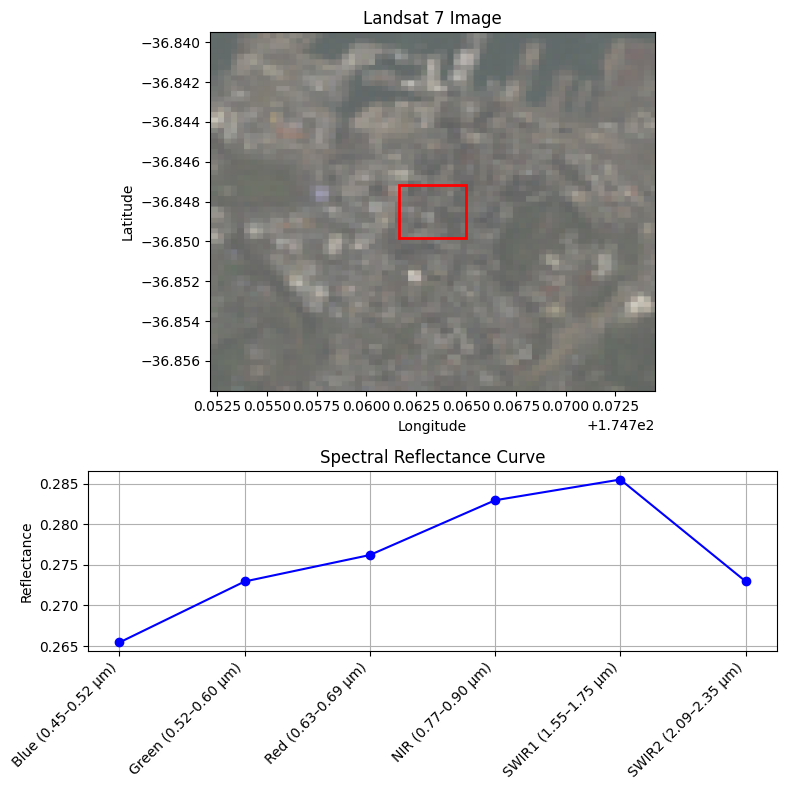

In [23]:
# Additional required packages
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg

# Define point and regions
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

# Define bands and scaling
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5

# Calculate mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands]
labels = list(band_names.values())

# Get RGB thumbnail slightly zoomed out
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region)
rxmin, rxmax, rymin, rymax = get_bounds_coords(region)

# Plot both panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

# Load and plot image with annotation
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Image")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add red rectangle for region of interest
    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

# Plot reflectance
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()


(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




Number of images in S2 collection after filtering: 13
Granules fully covering the ROI: 13
Mean cloud/shadow over the ROI, per scene: 15.34%
Mean scene-wide cloud from metadata, for comparison: 6.78%


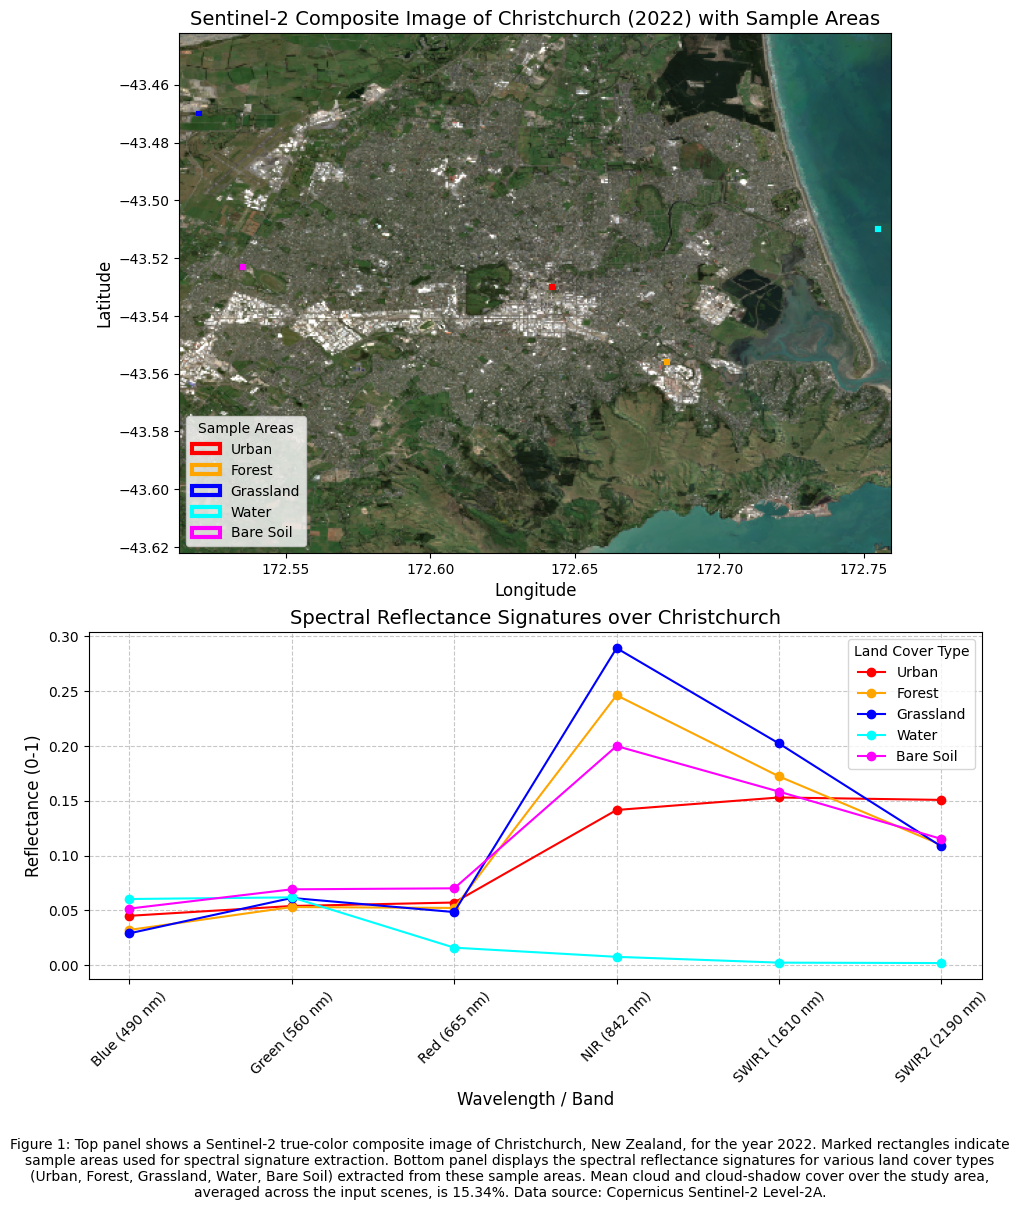

In [24]:
import ee
import geemap
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg

# --- Part 1: Define Region and Load Sentinel 2 Data ---

# Define Christchurch, NZ coordinates
christchurch_point = ee.Geometry.Point([172.6362, -43.5321])

# Define a larger region around Christchurch for context and calculations
christchurch_region_large = christchurch_point.buffer(10000).bounds() # 10km buffer

# Load Sentinel 2 Level-2A ImageCollection
# Filter for a specific year, e.g., 2022, over Christchurch
# Sort by cloud cover and take the least cloudy image
s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(christchurch_region_large) \
    .filterDate('2022-01-01', '2022-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) # Filter out images with >20% cloudy pixels

print(f"Number of images in S2 collection after filtering: {s2_collection.size().getInfo()}")

# --- Part 2: Basic Quality Assessment (Cloud Cover) ---

# Function to mask clouds for Sentinel-2 Level-2A using the SCL band
def mask_s2_clouds(image):
    scl = image.select('SCL')
    # Values to mask from SCL band (e.g., clouds, cloud shadows, cirrus)
    # 3 = Cloud shadow, 8 = Medium probability clouds, 9 = High probability clouds, 10 = Cirrus
    # Optionally, 1 (saturated/defective) or 6 (water) can also be masked
    cloud_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(cloud_mask)

# Keep only granules that fully cover the ROI. Christchurch sits near an MGRS
# tile edge, and no-data outside a granule footprint would otherwise be counted
# as cloud.
s2_collection = s2_collection.filter(
    ee.Filter.contains(leftField='.geo', rightValue=christchurch_region_large))
print(f"Granules fully covering the ROI: {s2_collection.size().getInfo()}")

# Per-scene cloud cover measured over the ROI rather than the whole footprint.
# Both counts are pixel counts at the same scale, so the ratio is dimensionless.
# Cloud cover is measured on the individual scenes, not on the annual median
# composite: a median of many <20% cloud scenes has valid data almost
# everywhere, so it would report ~0% no matter how cloudy the year actually was.
def roi_cloud_pct(image):
    n_data = image.select('B4').reduceRegion(
        reducer=ee.Reducer.count(), geometry=christchurch_region_large,
        scale=60, maxPixels=1e9).get('B4')
    n_clear = mask_s2_clouds(image).select('B4').reduceRegion(
        reducer=ee.Reducer.count(), geometry=christchurch_region_large,
        scale=60, maxPixels=1e9).get('B4')
    pct = ee.Number(1).subtract(ee.Number(n_clear).divide(n_data)).multiply(100)
    return ee.Feature(None, {'cloud_pct': pct})

estimated_cloud_coverage_percentage = (
    s2_collection.map(roi_cloud_pct).aggregate_mean('cloud_pct').getInfo())
scene_cloud_mean = s2_collection.aggregate_mean('CLOUDY_PIXEL_PERCENTAGE').getInfo()

print(f"Mean cloud/shadow over the ROI, per scene: {estimated_cloud_coverage_percentage:.2f}%")
print(f"Mean scene-wide cloud from metadata, for comparison: {scene_cloud_mean:.2f}%")

# Median composite still used for visualisation and spectral extraction.
composite_image = s2_collection.map(mask_s2_clouds).median()

# --- Part 3: Spectral Signature Extraction ---

# Define sample points for different land cover types within Christchurch
# These points are illustrative and might need manual adjustment for accuracy
sample_points = {
    'Urban': ee.Geometry.Point([172.6420, -43.5300]), # Central Christchurch
    'Forest': ee.Geometry.Point([172.6820, -43.5560]), # Port Hills area
    'Grassland': ee.Geometry.Point([172.5200, -43.4700]), # Rural/agricultural area
    'Water': ee.Geometry.Point([172.7550, -43.5100]),  # Estuary/coastline
    'Bare Soil': ee.Geometry.Point([172.5350, -43.5230]) # Example of exposed ground (can be construction, barren land etc.)
}

# Define Sentinel-2 bands for spectral analysis (SR bands)
# B2: Blue, B3: Green, B4: Red, B8: NIR, B11: SWIR1, B12: SWIR2
s2_bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12']
s2_band_names_full = {
    'B2': 'Blue (490 nm)',
    'B3': 'Green (560 nm)',
    'B4': 'Red (665 nm)',
    'B8': 'NIR (842 nm)',
    'B11': 'SWIR1 (1610 nm)',
    'B12': 'SWIR2 (2190 nm)'
}

# Scale factor for Sentinel-2 Level-2A Surface Reflectance (already scaled by 10000)
# To get reflectance from 0-1, we divide by 10000.
scale_s2_reflectance = 1e-4

spectral_signatures = {}
sample_areas_for_map = [] # To store small buffers around sample points for visualization

for lc_type, point_geom in sample_points.items():
    # Create a small buffer around each point to act as a sample area for the map
    sample_area_geometry = point_geom.buffer(30).bounds() # 30m buffer (approx 3x3 S2 pixels)
    # Create an ee.Feature from the geometry and set the 'label' property.
    sample_areas_for_map.append(ee.Feature(sample_area_geometry, {'label': lc_type}))

    # Reduce region to get mean reflectance for the sample point
    mean_dict = composite_image.select(s2_bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=point_geom.buffer(30), # 30m buffer for point sample
        scale=10,
        maxPixels=1e9
    ).getInfo()

    # Extract and scale values if mean_dict is not None and has data
    if mean_dict:
        reflectance_values = [mean_dict.get(b) * scale_s2_reflectance if mean_dict.get(b) is not None else 0 for b in s2_bands]
        spectral_signatures[lc_type] = reflectance_values
    else:
        print(f"Warning: No data found for {lc_type} sample area.")
        spectral_signatures[lc_type] = [None] * len(s2_bands)

# --- Part 4: Visualization (Publication Quality Figure) ---

# Get RGB thumbnail of the composite image for visualization
thumb_params = {
    'dimensions': 512,
    'region': christchurch_region_large, # Use the larger region for context
    'format': 'png',
    'bands': ['B4', 'B3', 'B2'], # Red, Green, Blue for true color
    'min': 0, # Sentinel-2 SR values are 0-10000
    'max': 3000, # Adjust max for better visual contrast if needed
    'gamma': 1.4
}
url = composite_image.getThumbURL(thumb_params)

# Get coordinates of the large region for the map extent
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

xmin, xmax, ymin, ymax = get_bounds_coords(christchurch_region_large)

# Create the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [1.5, 1]})

# Plot 1: Image thumbnail with sample areas
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Sentinel-2 Composite Image of Christchurch (2022) with Sample Areas", fontsize=14)
    ax1.set_xlabel("Longitude", fontsize=12)
    ax1.set_ylabel("Latitude", fontsize=12)
    ax1.tick_params(axis='x', labelsize=10)
    ax1.tick_params(axis='y', labelsize=10)

    # Add rectangles/points for sample areas
    colors = ['red', 'orange', 'blue', 'cyan', 'magenta'] # Colors for different land cover types
    for i, sample_area_feature in enumerate(sample_areas_for_map):
        lc_type = sample_area_feature.get('label').getInfo()
        # Pass the geometry of the feature to get_bounds_coords
        rxmin, rxmax, rymin, rymax = get_bounds_coords(sample_area_feature.geometry())
        width = rxmax - rxmin
        height = rymax - rymin
        rect = patches.Rectangle((rxmin, rymin), width, height,
                                 linewidth=3, edgecolor=colors[i % len(colors)], facecolor='none',
                                 label=lc_type)
        ax1.add_patch(rect)

    ax1.legend(loc='lower left', fontsize=10, title="Sample Areas")

# Plot 2: Spectral Reflectance Curves
ax2.set_title("Spectral Reflectance Signatures over Christchurch", fontsize=14)
ax2.set_xlabel("Wavelength / Band", fontsize=12)
ax2.set_ylabel("Reflectance (0-1)", fontsize=12)
ax2.tick_params(axis='x', labelsize=10, rotation=45)
ax2.tick_params(axis='y', labelsize=10)

for i, (lc_type, reflectance_data) in enumerate(spectral_signatures.items()):
    if all(r is not None for r in reflectance_data):
        ax2.plot(list(s2_band_names_full.values()), reflectance_data, marker='o', linestyle='-',
                 color=colors[i % len(colors)], label=lc_type)

ax2.legend(loc='upper right', fontsize=10, title="Land Cover Type")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.figtext(0.5, 0.00, # Adjust y position to fit caption
            f"Figure 1: Top panel shows a Sentinel-2 true-color composite image of Christchurch, New Zealand, for the year 2022. Marked rectangles indicate sample areas used for spectral signature extraction. Bottom panel displays the spectral reflectance signatures for various land cover types (Urban, Forest, Grassland, Water, Bare Soil) extracted from these sample areas. Mean cloud and cloud-shadow cover over the study area, averaged across the input scenes, is {estimated_cloud_coverage_percentage:.2f}%. Data source: Copernicus Sentinel-2 Level-2A.",
            wrap=True, ha='center', fontsize=10)
plt.subplots_adjust(bottom=0.18) # Make space for the caption
plt.show()